# Liberary Imports

In [1]:
# Import Essential Libraries
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.ensemble import VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [2]:
df_test = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv')
df_train = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv')
df_submission = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv')

# EDA

In [3]:
pd.set_option('display.max_columns', None)
df_train.head()

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,userId,trafficSource.campaign,device.mobileDeviceMarketingName,geoNetwork.networkDomain,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,geoNetwork.region,trafficSource,totals.visits,geoNetwork.networkLocation,sessionId,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,browserMajor,locationCountry,device.browserSize,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,locationZone,device.mobileDeviceModel,trafficSource.referralPath,totals.bounces,date,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,61421,(not set),not available in demo dataset,domain1,0,not available in demo dataset,1,not available in demo dataset,Washington,youtube.com,1,not available in demo dataset,1500100799,Windows,Northern America,referral,NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Redmond,NaN,Seattle-Tacoma WA,1.0,8,not available in demo dataset,/intl/hr/yt/about/,1.0,20170714,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,72287,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,California,(direct),1,not available in demo dataset,1495262065,Macintosh,Northern America,(none),NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,8,not available in demo dataset,NaN,1.0,20170519,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,25180,(not set),not available in demo dataset,domain1,0,not available in demo dataset,2,not available in demo dataset,Lombardy,google,1,not available in demo dataset,1508510328,Windows,Southern Europe,organic,NaN,not available in demo dataset,Italy,not available in demo dataset,NaN,Not Socially Engaged,Milan,NaN,(not set),6.0,8,not available in demo dataset,NaN,NaN,20171020,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,41295,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,not available in demo dataset,youtube.com,1,not available in demo dataset,1483431838,Windows,Eastern Asia,referral,NaN,not available in demo dataset,Japan,not available in demo dataset,NaN,Not Socially Engaged,not available in demo dataset,NaN,not available in demo dataset,1.0,8,not available in demo dataset,/yt/about/ja/,1.0,20170103,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,113697,(not set),not available in demo dataset,domain1,0,not available 

Finding the nukk values in total column-wise 

In [4]:
df_train.isnull().sum()

trafficSource.isTrueDirect                       73133
purchaseValue                                        0
browser                                              0
device.screenResolution                              0
trafficSource.adContent                         113060
trafficSource.keyword                            71861
screenSize                                           0
geoCluster                                           0
trafficSource.adwordsClickInfo.slot             111742
device.mobileDeviceBranding                          0
device.mobileInputSelector                           0
userId                                               0
trafficSource.campaign                               0
device.mobileDeviceMarketingName                     0
geoNetwork.networkDomain                             0
gclIdPresent                                         0
device.operatingSystemVersion                        0
sessionNumber                                        0
device.fla

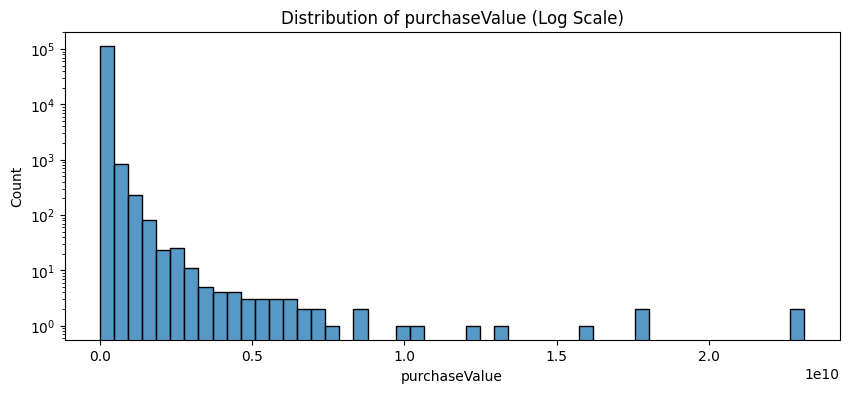


Unique values in browser: 34

Unique values in deviceType: 3

Unique values in trafficSource.medium: 7

Unique values in geoNetwork.region: 388


,pageViews,totalHits,sessionNumber
count,116015.000000,116023.000000,116023.000000
mean,8.412352,10.607371,2.691311
std,14.344937,19.629576,10.451613
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,1.000000
75%,10.000000,12.000000,2.000000
max,469.000000,500.000000,447.000000


In [5]:
# getting to know about our target variable Purchase Value 
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(10, 4))
sns.histplot(df_train['purchaseValue'], bins=50, kde=False)
plt.title("Distribution of purchaseValue (Log Scale)")
plt.yscale('log')  # Log scale due to skewness
plt.show()

# Categorical features
cat_cols = ['browser', 'deviceType', 'trafficSource.medium', 'geoNetwork.region']
for col in cat_cols:
    print(f"\nUnique values in {col}: {df_train[col].nunique()}")

# Numerical features
num_cols = ['pageViews', 'totalHits', 'sessionNumber']
df_train[num_cols].describe()



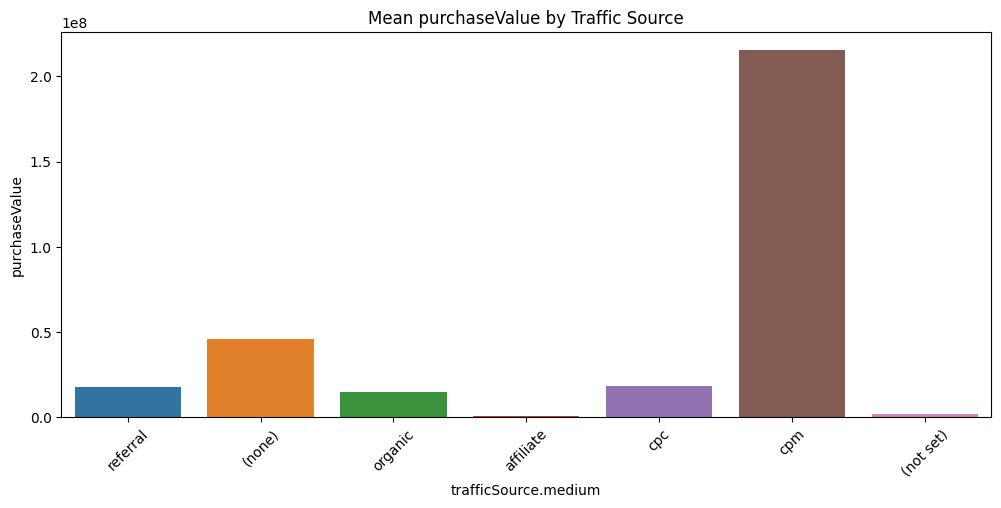

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(
    x='trafficSource.medium', 
    y='purchaseValue', 
    data=df_train, 
    estimator=np.mean,  # Showing mean purchase value per category
    ci=None
)
plt.xticks(rotation=45)
plt.title("Mean purchaseValue by Traffic Source")
plt.show()

In [7]:
# Zero-inflation
zero_pct = (df_train['purchaseValue'] == 0).mean() * 100
print(f"Percentage of zero purchaseValue: {zero_pct:.2f}%")

# Outlier detection(page view)
Q1, Q3 = df_train['pageViews'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df_train[df_train['pageViews'] > upper_bound]
print(f"PageViews outliers: {len(outliers)}")

Percentage of zero purchaseValue: 79.33%
PageViews outliers: 12419


# Data Cleaning 
## Handling Missing Values

In [8]:
# Calculate missing value percentages
train_missing = df_train.isnull().mean() * 100
test_missing = df_test.isnull().mean() * 100

# Find columns with >70% missing in both datasets
high_missing_train = set(train_missing[train_missing > 70].index)
high_missing_test = set(test_missing[test_missing > 70].index)
cols_to_drop = list(high_missing_train & high_missing_test)
df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

print(f"total Dropped {len(cols_to_drop)} columns")

total Dropped 5 columns


In [9]:
potential_id_cols = ['userId', 'sessionId']
df_train = df_train.drop(columns=[col for col in potential_id_cols if col in df_train.columns], errors='ignore')
df_test = df_test.drop(columns=[col for col in potential_id_cols if col in df_test.columns], errors='ignore')

In [10]:
numeric_cols_train = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_test = df_test.select_dtypes(include=[np.number]).columns.tolist()

df_train[numeric_cols_train] = df_train[numeric_cols_train].apply(pd.to_numeric, errors='coerce')
df_test[numeric_cols_test] = df_test[numeric_cols_test].apply(pd.to_numeric, errors='coerce')


In [11]:
# Drop columns with only one unique value in train set (also from test set)
single_val_col = [col for col in df_train.columns if df_train[col].nunique(dropna=True) == 1]
df_train.drop(columns=single_val_col, inplace=True, errors='ignore')
df_test.drop(columns=single_val_col, inplace=True, errors='ignore')
print(f"Removed {len(single_val_col)} single-unique columns: {single_val_col}")


Removed 20 single-unique columns: ['trafficSource.isTrueDirect', 'device.screenResolution', 'screenSize', 'device.mobileDeviceBranding', 'device.mobileInputSelector', 'device.mobileDeviceMarketingName', 'device.operatingSystemVersion', 'device.flashVersion', 'totals.visits', 'geoNetwork.networkLocation', 'browserMajor', 'device.browserSize', 'socialEngagementType', 'locationZone', 'device.mobileDeviceModel', 'totals.bounces', 'device.language', 'device.browserVersion', 'device.screenColors', 'new_visits']


In [12]:
print("Remaining columns after cleaning:")
print(df_train.columns.tolist())


Remaining columns after cleaning:
['purchaseValue', 'browser', 'trafficSource.keyword', 'geoCluster', 'trafficSource.campaign', 'geoNetwork.networkDomain', 'gclIdPresent', 'sessionNumber', 'geoNetwork.region', 'trafficSource', 'os', 'geoNetwork.subContinent', 'trafficSource.medium', 'locationCountry', 'geoNetwork.city', 'geoNetwork.metro', 'pageViews', 'trafficSource.referralPath', 'date', 'deviceType', 'userChannel', 'totalHits', 'sessionStart', 'geoNetwork.continent', 'device.isMobile']


In [13]:
df_train['sessionNumber'].describe()

count    116023.000000
mean          2.691311
std          10.451613
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         447.000000
Name: sessionNumber, dtype: float64

# Train-Test Split

In [14]:
X = df_train.drop('purchaseValue', axis=1)
y = df_train['purchaseValue']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape} features, {y_train.shape} labels")
print(f"Validation set: {X_val.shape} features, {y_val.shape} labels")

Training set: (92818, 24) features, (92818,) labels
Validation set: (23205, 24) features, (23205,) labels


In [15]:
# --- Feature Type Detection & Preprocessing Setup ---

def get_feature_types(df, target='purchaseValue', cat_threshold=10):
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if target in numeric:
        numeric.remove(target)
    cat_low, cat_high = [], []
    for c in categorical:
        if df[c].nunique() <= cat_threshold:
            cat_low.append(c)
        else:
            cat_high.append(c)
    return numeric, cat_low, cat_high

# Identify features for preprocessing
num_features, cat_features_low, cat_features_high = get_feature_types(X_train)

print(f"Numerical features: {num_features}")
print(f"Low-cardinality categoricals: {cat_features_low}")
print(f"High-cardinality categoricals: {cat_features_high}")

# Define transformers for each feature type
num_pipeline = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', RobustScaler()),
    ('power', PowerTransformer())
])

cat_pipeline_low = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_pipeline_high = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=15))
])

# Assemble the full preprocessing pipeline
feature_preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat_low', cat_pipeline_low, cat_features_low),
    ('cat_high', cat_pipeline_high, cat_features_high)
])

def build_pipeline(estimator):
    return Pipeline([
        ('features', feature_preprocessor),
        ('estimator', estimator)
    ])

print("New preprocessing pipeline done.")


Numerical features: ['gclIdPresent', 'sessionNumber', 'pageViews', 'date', 'totalHits', 'sessionStart']
Low-cardinality categoricals: ['geoCluster', 'geoNetwork.networkDomain', 'trafficSource.medium', 'deviceType', 'userChannel', 'geoNetwork.continent']
High-cardinality categoricals: ['browser', 'trafficSource.keyword', 'trafficSource.campaign', 'geoNetwork.region', 'trafficSource', 'os', 'geoNetwork.subContinent', 'locationCountry', 'geoNetwork.city', 'geoNetwork.metro', 'trafficSource.referralPath']
New preprocessing pipeline done.


In [16]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# # Define parameter distributions for RandomizedSearchCV
# param_dist = {
#     'estimator__n_estimators': randint(100, 1000),
#     'estimator__learning_rate': uniform(0.01, 0.1),
#     'estimator__max_depth': randint(3, 15),
#     'estimator__subsample': uniform(0.6, 0.4),
#     'estimator__colsample_bytree': uniform(0.6, 0.4),
#     'estimator__reg_alpha': uniform(0.0, 0.5),
#     'estimator__reg_lambda': uniform(0.0, 0.5)
# }

# # Build the pipeline for tuning (using the best model found earlier as the base)
# tune_pipe = build_pipeline(XGBRegressor(random_state=42, n_jobs=-1))

# # Set up RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     tune_pipe,
#     param_distributions=param_dist,
#     n_iter=50, # Number of parameter settings that are sampled.
#     cv=3,      # Number of folds for cross-validation
#     scoring='r2', # Use R^2 as the scoring metric
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# print("Starting hyperparameter tuning with RandomizedSearchCV...")
# random_search.fit(X_train, y_train)

# print("\nBest parameters found:")
# print(random_search.best_params_)

# print("\nBest cross-validation R^2 score:")
# print(random_search.best_score_)

# best_xgb_model = random_search.best_estimator_

# Model training 

In [17]:

# Define model configurations
model_configs = [
    {
        'name': 'XGBoost_Optimized',
        'estimator': XGBRegressor(
            n_estimators=430, 
            learning_rate=0.07, 
            max_depth=10, 
            subsample=0.90, 
            colsample_bytree=0.9, 
            reg_alpha=0.2, 
            reg_lambda=0.2, 
            random_state=42, 
            n_jobs=-1
        )

    },
    {
        'name': 'LightGBM_Optimized',
        'estimator': LGBMRegressor(
            n_estimators=400,
            learning_rate=0.06,
            max_depth=120,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.2,
            reg_lambda=0.2,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    },
    {
        'name': 'RandomForest_Optimized',
        'estimator': RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_split=3,
            min_samples_leaf=1,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
    }
]

results_summary = []
print("\n🔍 Evaluating models on validation set...\n" + "-"*60)

for config in model_configs:
    print(f"⏳ Fitting {config['name']}...")
    pipe = build_pipeline(config['estimator'])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    r2 = r2_score(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results_summary.append({
        'name': config['name'],
        'pipeline': pipe,
        'r2': r2,
        'rmse': rmse
    })
    print(f"    R²: {r2:.4f} | RMSE: {rmse:.2f}")

# Rank models by R² score
results_summary.sort(key=lambda x: x['r2'], reverse=True)
print("\n🏅 MODEL PERFORMANCE RANKING\n" + "="*60)
for idx, res in enumerate(results_summary, 1):
    tag = "🥇 WINNER" if idx == 1 else f"#{idx}"
    print(f"{tag} {res['name']}: R² = {res['r2']:.4f}, RMSE = {res['rmse']:.2f}")

# Select the best model
winning_pipeline = results_summary[0]['pipeline']
winning_model_name = results_summary[0]['name']
final_val_score = results_summary[0]['r2']

print(f"\n✅ Selected Model: {winning_model_name} with R² = {final_val_score:.4f}")



🔍 Evaluating models on validation set...
------------------------------------------------------------
⏳ Fitting XGBoost_Optimized...
    R²: 0.4021 | RMSE: 168118972.28
⏳ Fitting LightGBM_Optimized...
    R²: 0.2001 | RMSE: 194453857.30
⏳ Fitting RandomForest_Optimized...
    R²: 0.2968 | RMSE: 182311131.27

🏅 MODEL PERFORMANCE RANKING
🥇 WINNER XGBoost_Optimized: R² = 0.4021, RMSE = 168118972.28
#2 RandomForest_Optimized: R² = 0.2968, RMSE = 182311131.27
#3 LightGBM_Optimized: R² = 0.2001, RMSE = 194453857.30

✅ Selected Model: XGBoost_Optimized with R² = 0.4021


# Best Model Submission 

In [18]:
# Final Submission Generation Using the Best Model

print(f"🚀 Preparing submission using the top-performing model: {winning_model_name}")

# Combine training and validation sets for final training
X_complete = pd.concat([X_train, X_val], axis=0)
y_complete = pd.concat([y_train, y_val], axis=0)

# Retrain the best pipeline on all available data
winning_pipeline.fit(X_complete, y_complete)

# Predict on the test dataset
final_preds = winning_pipeline.predict(df_test)

# Ensure predictions are valid integers and non-negative
final_preds = np.clip(np.round(final_preds).astype(int), 0, None)

# Assemble the submission DataFrame
submission_df = pd.DataFrame({
    'id': np.arange(len(df_test)),
    'purchaseValue': final_preds
})

# Export the submission file
submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✅ Submission file created: {submission_path}")
print("🔢 Prediction Summary:")
print(submission_df['purchaseValue'].describe())

print("\n🏅 FINAL MODEL SUMMARY")
print(f"Model Used: {winning_model_name}")
print(f"Validation R² Score: {final_val_score:.4f}")
print(f"Submission File: {submission_path}")

# Optional: Display a summary of all model performances
print("\n📋 MODEL PERFORMANCE OVERVIEW")
print("=" * 50)
for idx, res in enumerate(results_summary, 1):
    symbol = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else f"#{idx}"
    print(f"{symbol} {res['name']}: R² = {res['r2']:.4f}, RMSE = {res['rmse']:.2f}")


🚀 Preparing submission using the top-performing model: XGBoost_Optimized
✅ Submission file created: submission.csv
🔢 Prediction Summary:
count    2.900600e+04
mean     2.870417e+07
std      1.475799e+08
min      0.000000e+00
25%      0.000000e+00
50%      6.024600e+04
75%      1.027898e+07
max      1.482944e+10
Name: purchaseValue, dtype: float64

🏅 FINAL MODEL SUMMARY
Model Used: XGBoost_Optimized
Validation R² Score: 0.4021
Submission File: submission.csv

📋 MODEL PERFORMANCE OVERVIEW
🥇 XGBoost_Optimized: R² = 0.4021, RMSE = 168118972.28
🥈 RandomForest_Optimized: R² = 0.2968, RMSE = 182311131.27
🥉 LightGBM_Optimized: R² = 0.2001, RMSE = 194453857.30
